1. Regression: Simple Models (Linear & Decision Tree)



--- Dataset Preview ---
  Gender     Height      Weight
0   Male  73.847017  241.893563
1   Male  68.781904  162.310473
2   Male  74.110105  212.740856
3   Male  71.730978  220.042470
4   Male  69.881796  206.349801

--- Missing Values ---
Gender    0
Height    0
Weight    0
dtype: int64


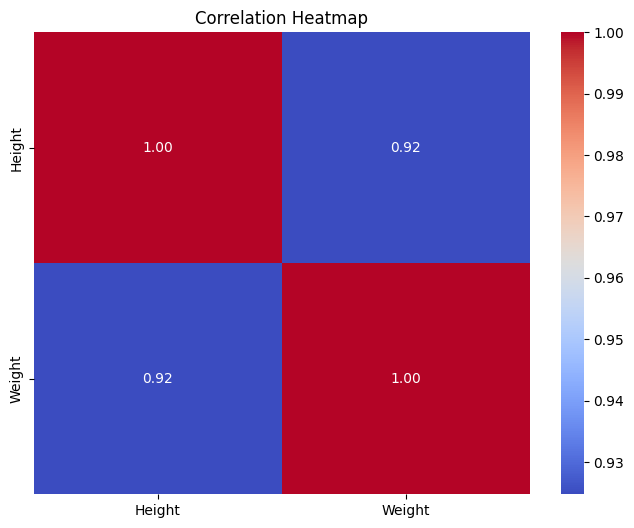


--- Linear Regression Evaluation ---
MSE: 104.73832247309385
RMSE: 10.23417424480812
MAE: 7.99861426581448
R²: 0.8999960770984344
Best DT Params: {'max_depth': 10, 'min_samples_split': 10}

--- Decision Tree (Tuned) Evaluation ---
MSE: 117.43835847003486
RMSE: 10.83689800957981
MAE: 8.439268571384016
R²: 0.887870110301406


In [ ]:
# === SIMPLE REGRESSION: LINEAR & DECISION TREE ===
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

# === 1. LOAD DATA ===
df = pd.read_csv("weight-height.csv")

# === 2. DEFINE TARGET AND FEATURES ===
target = "Weight"
features = [col for col in df.columns if col != target]

# === 3. INITIAL DATA CHECK (EDA) ===
print("\n--- Dataset Preview ---")
print(df.head())
print("\n--- Missing Values ---")
print(df.isnull().sum())
df.dropna(inplace=True) # Dropping simple NaNs as per your request

# === 4. VISUALIZE CORRELATION ===
plt.figure(figsize=(8, 6))
sns.heatmap(df.select_dtypes(include=np.number).corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

# === 5. PREPROCESSING ===
X = df[features]
y = df[target]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Handle missing values
for col in X_train.columns:
    if X_train[col].dtypes == 'object':
        mode_val = X_train[col].mode()[0]
        X_train[col] = X_train[col].fillna(mode_val)
        X_test[col] = X_test[col].fillna(mode_val)
    else:
        median_val = X_train[col].median()
        X_train[col] = X_train[col].fillna(median_val)
        X_test[col] = X_test[col].fillna(median_val)

# Handle outliers (IQR)
for col in X_train.select_dtypes(include=np.number).columns:
    Q1 = X_train[col].quantile(0.25)
    Q3 = X_train[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    median_val = X_train[col].median()
    X_train[col] = np.where((X_train[col] < lower) | (X_train[col] > upper), median_val, X_train[col])
    X_test[col] = np.where((X_test[col] < lower) | (X_test[col] > upper), median_val, X_test[col])

# Encode & Align
X_train_enc = pd.get_dummies(X_train)
X_test_enc = pd.get_dummies(X_test)
X_train_final, X_test_final = X_train_enc.align(X_test_enc, join='left', axis=1, fill_value=0)

# Scale (Required for Linear Regression)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_final)
X_test_scaled = scaler.transform(X_test_final)

# Evaluation Function
def evaluate_model(name, y_true, y_pred):
    print(f"\n--- {name} Evaluation ---")
    print("MSE:", mean_squared_error(y_true, y_pred))
    print("RMSE:", np.sqrt(mean_squared_error(y_true, y_pred)))
    print("MAE:", mean_absolute_error(y_true, y_pred))
    print("R²:", r2_score(y_true, y_pred))

# === 6. TRAIN SIMPLE MODELS ===

## 🔹 Linear Regression (Baseline)
lin_model = LinearRegression()
lin_model.fit(X_train_scaled, y_train)
lin_pred = lin_model.predict(X_test_scaled)
evaluate_model("Linear Regression", y_test, lin_pred)

## 🔹 Decision Tree (UNTUNED / BASE)
dt_untuned = DecisionTreeRegressor(random_state=42)
dt_untuned.fit(X_train_final, y_train)
dt_untuned_pred = dt_untuned.predict(X_test_final)
evaluate_model("Decision Tree (Untuned)", y_test, dt_untuned_pred)

## 🔹 Decision Tree (TUNED / GridSearch)
dt_base = DecisionTreeRegressor(random_state=42)
dt_params = {
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5, 10]
}
grid_dt = GridSearchCV(dt_base, dt_params, cv=5, scoring='neg_mean_squared_error', n_jobs=-1)
grid_dt.fit(X_train_final, y_train)

dt_model = grid_dt.best_estimator_ # The best model found
print(f"Best DT Params: {grid_dt.best_params_}")
dt_pred = dt_model.predict(X_test_final)
evaluate_model("Decision Tree (Tuned)", y_test, dt_pred)

2. Regression: Advanced Models (RF & Neural Network)



--- Dataset Preview ---
  Gender     Height      Weight
0   Male  73.847017  241.893563
1   Male  68.781904  162.310473
2   Male  74.110105  212.740856
3   Male  71.730978  220.042470
4   Male  69.881796  206.349801

--- Missing Values ---
Gender    0
Height    0
Weight    0
dtype: int64


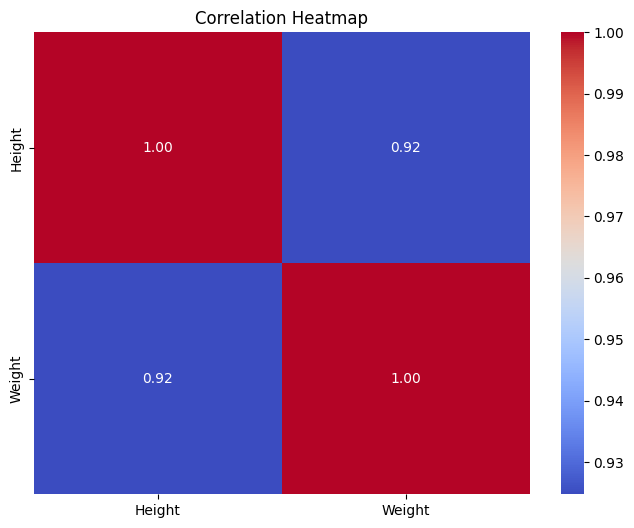

Best RF Params: {'max_depth': 10, 'n_estimators': 100}

--- Random Forest (Tuned) Evaluation ---
MSE: 108.08678793359977
RMSE: 10.3964795932854
MAE: 8.188022112364456
R²: 0.8967989695465447
Best NN Params: {'activation': 'relu', 'hidden_layer_sizes': (100,), 'solver': 'adam'}

--- Neural Network (Tuned) Evaluation ---
MSE: 104.76363262444856
RMSE: 10.235410720847922
MAE: 7.994372463860147
R²: 0.8999719110208714


In [ ]:
# === ADVANCED REGRESSION: RANDOM FOREST & NEURAL NETWORK ===
# === ADVANCED REGRESSION: RF & NN (UNTUNED vs TUNED) ===

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

# === 1. LOAD DATA ===
df = pd.read_csv("weight-height.csv")

# === 2. DEFINE TARGET AND FEATURES ===
target = "Weight"
features = [col for col in df.columns if col != target]

# === 3. EDA ===
print("\n--- Dataset Preview ---")
print(df.head())
print("\n--- Missing Values ---")
print(df.isnull().sum())
df.dropna(inplace=True)

plt.figure(figsize=(8, 6))
sns.heatmap(df.select_dtypes(include=np.number).corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

# === 4. PREPROCESSING ===
X = df[features]
y = df[target]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Handle missing values
for col in X_train.columns:
    if X_train[col].dtypes == 'object':
        mode_val = X_train[col].mode()[0]
        X_train[col] = X_train[col].fillna(mode_val)
        X_test[col] = X_test[col].fillna(mode_val)
    else:
        median_val = X_train[col].median()
        X_train[col] = X_train[col].fillna(median_val)
        X_test[col] = X_test[col].fillna(median_val)

# Handle outliers (IQR)
for col in X_train.select_dtypes(include=np.number).columns:
    Q1 = X_train[col].quantile(0.25)
    Q3 = X_train[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    median_val = X_train[col].median()
    X_train[col] = np.where((X_train[col] < lower) | (X_train[col] > upper), median_val, X_train[col])
    X_test[col] = np.where((X_test[col] < lower) | (X_test[col] > upper), median_val, X_test[col])

# Encode & Align
X_train_enc = pd.get_dummies(X_train)
X_test_enc = pd.get_dummies(X_test)
X_train_final, X_test_final = X_train_enc.align(X_test_enc, join='left', axis=1, fill_value=0)

# Scale (Required for NN)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_final)
X_test_scaled = scaler.transform(X_test_final)

# Evaluation Function
def evaluate_model(name, y_true, y_pred):
    print(f"\n--- {name} Evaluation ---")
    print("MSE:", mean_squared_error(y_true, y_pred))
    print("RMSE:", np.sqrt(mean_squared_error(y_true, y_pred)))
    print("MAE:", mean_absolute_error(y_true, y_pred))
    print("R²:", r2_score(y_true, y_pred))

# === 5. TRAIN ADVANCED MODELS ===

## 🔹 Random Forest (UNTUNED)
rf_untuned = RandomForestRegressor(random_state=42)
rf_untuned.fit(X_train_final, y_train)
rf_untuned_pred = rf_untuned.predict(X_test_final)
evaluate_model("Random Forest (Untuned)", y_test, rf_untuned_pred)

## 🔹 Random Forest (TUNED)
rf_base = RandomForestRegressor(random_state=42, n_jobs=-1)
rf_params = {'n_estimators': [50, 100], 'max_depth': [None, 10, 20]}
grid_rf = GridSearchCV(rf_base, rf_params, cv=5, scoring='neg_mean_squared_error', n_jobs=-1)
grid_rf.fit(X_train_final, y_train)

rf_model = grid_rf.best_estimator_
print(f"Best RF Params: {grid_rf.best_params_}")
rf_pred = rf_model.predict(X_test_final)
evaluate_model("Random Forest (Tuned)", y_test, rf_pred)

## 🔹 Neural Network (UNTUNED)
nn_untuned = MLPRegressor(random_state=42, max_iter=1000)
nn_untuned.fit(X_train_scaled, y_train)
nn_untuned_pred = nn_untuned.predict(X_test_scaled)
evaluate_model("Neural Network (Untuned)", y_test, nn_untuned_pred)

## 🔹 Neural Network (TUNED)
nn_base = MLPRegressor(max_iter=1000, random_state=42)
nn_params = {
    'hidden_layer_sizes': [(64, 32), (100,)], 
    'activation': ['relu', 'tanh'],
    'solver': ['adam']
}
grid_nn = GridSearchCV(nn_base, nn_params, cv=3, scoring='neg_mean_squared_error', n_jobs=-1)
grid_nn.fit(X_train_scaled, y_train)

nn_model = grid_nn.best_estimator_
print(f"Best NN Params: {grid_nn.best_params_}")
nn_pred = nn_model.predict(X_test_scaled)
evaluate_model("Neural Network (Tuned)", y_test, nn_pred)


3. Classification: Simple Models (Logistic & Decision Tree)

--- Dataset Head ---
   enrollee_id      city  city_development_index gender  \
0         8949  city_103                   0.920   Male   
1        29725   city_40                   0.776   Male   
2        11561   city_21                   0.624    NaN   
3        33241  city_115                   0.789    NaN   
4          666  city_162                   0.767   Male   

       relevent_experience enrolled_university education_level  \
0  Has relevent experience       no_enrollment        Graduate   
1   No relevent experience       no_enrollment        Graduate   
2   No relevent experience    Full time course        Graduate   
3   No relevent experience                 NaN        Graduate   
4  Has relevent experience       no_enrollment         Masters   

  major_discipline  experience company_size    company_type  training_hours  \
0             STEM        20.0          NaN             NaN            36.0   
1             STEM        15.0        50-99         Pvt Ltd          

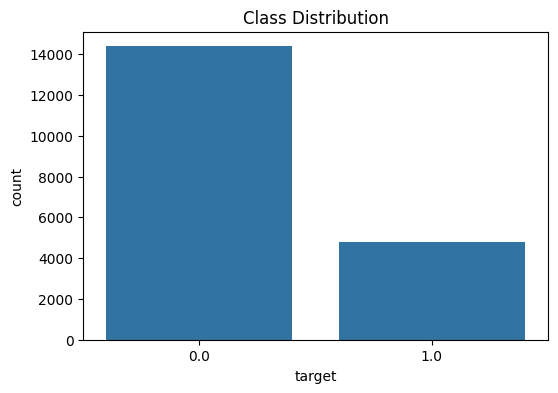


--- Logistic Regression Evaluation ---
Accuracy: 0.7755741127348643
Recall: 0.7755741127348643
Confusion Matrix:
 [[2661  216]
 [ 644  311]]
Classification Report:
               precision    recall  f1-score   support

         0.0       0.81      0.92      0.86      2877
         1.0       0.59      0.33      0.42       955

    accuracy                           0.78      3832
   macro avg       0.70      0.63      0.64      3832
weighted avg       0.75      0.78      0.75      3832

Best DT Params: {'max_depth': 10, 'min_samples_split': 10}

--- Decision Tree (Tuned) Evaluation ---
Accuracy: 0.7768789144050104
Recall: 0.7768789144050104
Confusion Matrix:
 [[2458  419]
 [ 436  519]]
Classification Report:
               precision    recall  f1-score   support

         0.0       0.85      0.85      0.85      2877
         1.0       0.55      0.54      0.55       955

    accuracy                           0.78      3832
   macro avg       0.70      0.70      0.70      3832
weighted

In [ ]:
# === SIMPLE CLASSIFICATION: LOGISTIC & DECISION TREE ===
# === SIMPLE CLASSIFICATION: LOGISTIC & DT (UNTUNED vs TUNED) ===

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, recall_score, classification_report, confusion_matrix

# === 1. LOAD DATA & EDA ===
df = pd.read_csv("data_science_job.csv")
target = "target"
df.dropna(subset=[target], inplace=True)

print(df.head())
print(df.isnull().sum())
plt.figure(figsize=(6, 4))
sns.countplot(x=target, data=df)
plt.title("Class Distribution")
plt.show()

# === 2. PREPROCESSING ===
X = df.drop(target, axis=1)
y = df[target]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Imputation
for col in X_train.columns:
    if X_train[col].dtypes == "object":
        mode_val = X_train[col].mode()[0]
        X_train[col] = X_train[col].fillna(mode_val)
        X_test[col] = X_test[col].fillna(mode_val)
    else:
        median_val = X_train[col].median()
        X_train[col] = X_train[col].fillna(median_val)
        X_test[col] = X_test[col].fillna(median_val)

# Encoding & Scaling
X_train_encoded = pd.get_dummies(X_train)
X_test_encoded = pd.get_dummies(X_test)
X_train_final, X_test_final = X_train_encoded.align(X_test_encoded, axis=1, fill_value=0, join="left")

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_final)
X_test_scaled = scaler.transform(X_test_final)

# Evaluation Function
def evaluate_model(name, y_true, y_pred):
    print(f"\n--- {name} Evaluation ---")
    print("Accuracy:", accuracy_score(y_true, y_pred))
    print("Recall:", recall_score(y_true, y_pred, average='weighted'))
    print("Classification Report:\n", classification_report(y_true, y_pred))

# === 3. TRAIN SIMPLE MODELS ===

## 🔹 Logistic Regression (Baseline)
log_model = LogisticRegression(max_iter=1000, random_state=42)
log_model.fit(X_train_scaled, y_train)
log_pred = log_model.predict(X_test_scaled)
evaluate_model("Logistic Regression", y_test, log_pred)

## 🔹 Decision Tree (UNTUNED)
dt_untuned = DecisionTreeClassifier(random_state=42)
dt_untuned.fit(X_train_final, y_train)
dt_untuned_pred = dt_untuned.predict(X_test_final)
evaluate_model("Decision Tree (Untuned)", y_test, dt_untuned_pred)

## 🔹 Decision Tree (TUNED)
dt_base = DecisionTreeClassifier(random_state=42)
dt_params = {'max_depth': [None, 10, 20], 'min_samples_split': [2, 5, 10]}
grid_dt = GridSearchCV(dt_base, dt_params, cv=5, scoring='accuracy', n_jobs=-1)
grid_dt.fit(X_train_final, y_train)

dt_model = grid_dt.best_estimator_
print(f"Best DT Params: {grid_dt.best_params_}")
dt_pred = dt_model.predict(X_test_final)
evaluate_model("Decision Tree (Tuned)", y_test, dt_pred)

4. Classification: Advanced Models (RF & Neural Network)

In [ ]:
# === ADVANCED CLASSIFICATION: RANDOM FOREST & NEURAL NETWORK ===
# === ADVANCED CLASSIFICATION: RF & NN (UNTUNED vs TUNED) ===

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, recall_score, classification_report, confusion_matrix

# === 1. LOAD DATA & EDA ===
df = pd.read_csv("data_science_job.csv")
target = "target"
df.dropna(subset=[target], inplace=True)

print(df.head())
print(df.isnull().sum())
plt.figure(figsize=(6, 4))
sns.countplot(x=target, data=df)
plt.title("Class Distribution")
plt.show()

# === 2. PREPROCESSING ===
X = df.drop(target, axis=1)
y = df[target]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Imputation
for col in X_train.columns:
    if X_train[col].dtypes == "object":
        mode_val = X_train[col].mode()[0]
        X_train[col] = X_train[col].fillna(mode_val)
        X_test[col] = X_test[col].fillna(mode_val)
    else:
        median_val = X_train[col].median()
        X_train[col] = X_train[col].fillna(median_val)
        X_test[col] = X_test[col].fillna(median_val)

# Encoding & Scaling
X_train_encoded = pd.get_dummies(X_train)
X_test_encoded = pd.get_dummies(X_test)
X_train_final, X_test_final = X_train_encoded.align(X_test_encoded, axis=1, fill_value=0, join="left")

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_final)
X_test_scaled = scaler.transform(X_test_final)

# Evaluation Function
def evaluate_model(name, y_true, y_pred):
    print(f"\n--- {name} Evaluation ---")
    print("Accuracy:", accuracy_score(y_true, y_pred))
    print("Recall:", recall_score(y_true, y_pred, average='weighted'))
    print("Classification Report:\n", classification_report(y_true, y_pred))

# === 3. TRAIN ADVANCED MODELS ===

## 🔹 Random Forest (UNTUNED)
rf_untuned = RandomForestClassifier(random_state=42)
rf_untuned.fit(X_train_final, y_train)
rf_untuned_pred = rf_untuned.predict(X_test_final)
evaluate_model("Random Forest (Untuned)", y_test, rf_untuned_pred)

## 🔹 Random Forest (TUNED)
rf_base = RandomForestClassifier(random_state=42, n_jobs=-1)
rf_params = {'n_estimators': [50, 100], 'max_depth': [None, 10, 20]}
grid_rf = GridSearchCV(rf_base, rf_params, cv=5, scoring='accuracy', n_jobs=-1)
grid_rf.fit(X_train_final, y_train)

rf_model = grid_rf.best_estimator_
print(f"Best RF Params: {grid_rf.best_params_}")
rf_pred = rf_model.predict(X_test_final)
evaluate_model("Random Forest (Tuned)", y_test, rf_pred)

## 🔹 Neural Network (UNTUNED)
nn_untuned = MLPClassifier(random_state=42, max_iter=1000)
nn_untuned.fit(X_train_scaled, y_train)
nn_untuned_pred = nn_untuned.predict(X_test_scaled)
evaluate_model("Neural Network (Untuned)", y_test, nn_untuned_pred)

## 🔹 Neural Network (TUNED)
nn_base = MLPClassifier(max_iter=1000, random_state=42)
nn_params = {
    'hidden_layer_sizes': [(64, 32), (100,)], 
    'activation': ['relu', 'tanh'],
    'solver': ['adam']
}
grid_nn = GridSearchCV(nn_base, nn_params, cv=3, scoring='accuracy', n_jobs=-1)
grid_nn.fit(X_train_scaled, y_train)

nn_model = grid_nn.best_estimator_
print(f"Best NN Params: {grid_nn.best_params_}")
nn_pred = nn_model.predict(X_test_scaled)
evaluate_model("Neural Network (Tuned)", y_test, nn_pred)